# Laos (must-take port)

PREP-SHOT validation against the Laos case study from PowNet
(Chowdhury et al. 2020).  Laos 2016: 69 demand buses, 5 thermal
units, **30 hydropower plants** (the dominant carrier -- Laos is
a regional hydro exporter), 4 international import nodes
(EGAT-Sirindhorn, ChinMengLa, EGAT-Bungkan, EGAT-Mukdahan).

**Why Laos is interesting.**  Cambodia's case (companion notebook)
is thermal-dominated with a small hydro base; Laos is the opposite
-- annual hydro generation (~24 TWh) approximately equals annual
demand+export (~30 TWh of which 5+ TWh are exports).  The
must-take port locks all 30 hydro plants and 4 import nodes to
the exogenous profiles, leaving the LP to dispatch only 5
thermals (3 coal, 2 biomass) at the margin.

Same conventions and caveats as `Cambodia.ipynb`: single-bus
aggregation, augmented demand for export absorption, median-of-
year fuel prices.

## 1. Data sources and references

**Primary citation.**  
Chowdhury, A. F. M. K., Kern, J., Dang, T. D., Galelli, S. (2020).
"PowNet: A Network-Constrained Unit Commitment / Economic
Dispatch Model for Large-Scale Power Systems Analysis."
*Journal of Open Research Software*, 8(1): 5. 
https://doi.org/10.5334/jors.302

**Dataset.** [`kamal0013/PowNet @ v2.1`](https://github.com/kamal0013/PowNet/tree/v2.1/model_library/laos)
with seven CSVs in the same schema as Cambodia (`unit_param`,
`demand_export`, `hydro`, `import`, `fuel_price`, `derate_factor`,
`transmission`, plus a `fuel_map.csv` Laos-specific table mapping
plant -> fuel).

**Reference comparison.**  No published per-generator output is
shipped in the PowNet repo for Laos 2016 (unlike Cambodia, which
has `out_camb_R1_2016_mwh.csv`).  We validate by structural
agreement with Chowdhury et al. (2020):

* Hydro >> 80 % of total annual generation (true hydro-export
  system).
* Imports modest (~14 %).
* Thermals (coal + biomass) marginal (< 5 %).

## 2. Inventory and load profile

In [1]:
import pathlib, os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

this_dir = pathlib.Path.cwd()
while this_dir.name != 'laos':
    if this_dir == this_dir.parent:
        raise RuntimeError('run from inside examples/laos/')
    this_dir = this_dir.parent
INP = this_dir / 'input'

fleet = pd.read_csv(INP / 'tech_existing.csv').merge(
    pd.read_csv(INP / 'tech_registry.csv')[['tech', 'carrier']], on='tech',
)
demand = pd.read_csv(INP / 'demand.csv')
by_carrier = fleet.groupby('carrier').agg(
    n=('tech', 'count'), nameplate_mw=('capacity', 'sum'),
)
print('Fleet by carrier:')
print(by_carrier.to_string())
print(f'\nAugmented annual demand (incl. implied exports): '
      f'{demand.value.sum() / 1e6:.2f} TWh')
print(f'Peak hour: {demand.value.idxmax() + 1}  '
      f'({demand.value.max():.0f} MW)')

Fleet by carrier:
          n  nameplate_mw
carrier                  
biomass   2          39.7
coal      3        1878.0
hydro    30        4764.1
import    4         496.0

Augmented annual demand (incl. implied exports): 29.77 TWh
Peak hour: 6025  (5076 MW)


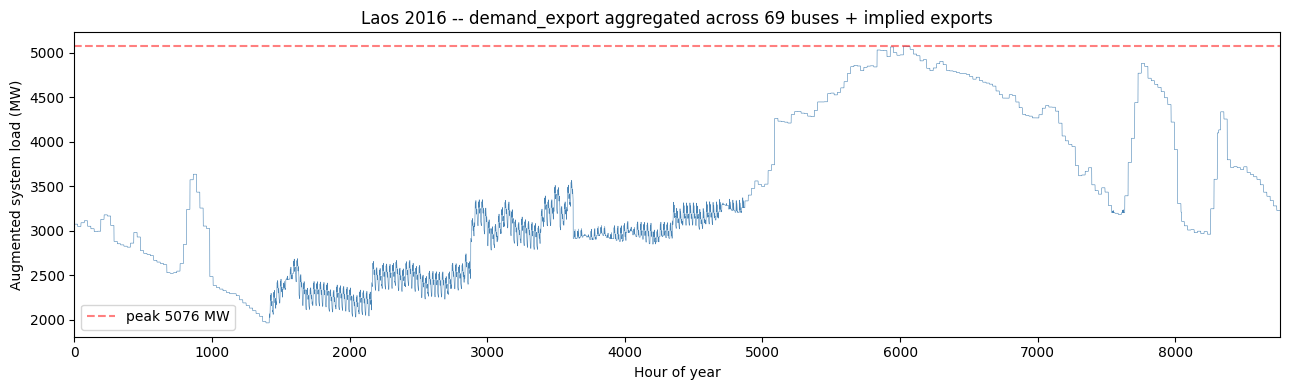

In [2]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(demand['hour'], demand['value'], color='steelblue', linewidth=0.4)
ax.axhline(demand.value.max(), color='red', linestyle='--', alpha=0.5,
           label=f'peak {demand.value.max():.0f} MW')
ax.set_xlabel('Hour of year'); ax.set_ylabel('Augmented system load (MW)')
ax.set_title('Laos 2016 -- demand_export aggregated across 69 buses + implied exports')
ax.legend(); ax.set_xlim(0, 8760)
plt.tight_layout(); plt.show()

## 3. Run full-year PCM

```bash
cd examples/laos
python -m prepshot.pcm . --year 2016 --horizon 24 --step 24
```

Wall time ~13 s.  Output is cached at `output/baseline_pcm/`.

In [3]:
OUT_PARQUET = this_dir / 'output' / 'baseline_pcm' / 'gen.parquet'
if OUT_PARQUET.exists():
    print(f'Using cached output at {OUT_PARQUET.relative_to(this_dir)}')
    gen_df = pd.read_parquet(OUT_PARQUET)
else:
    sys.argv = [sys.argv[0]]
    os.chdir(this_dir)
    from prepshot.set_up import initialize_environment
    from prepshot.pcm import (
        _build_window_params, _override_existing_fleet,
        load_fixed_capacity, _extract_window_dispatch,
    )
    from prepshot.model import create_model
    from prepshot.solver import solve_model
    full_params = initialize_environment({
        'filepath': str(this_dir),
        'config_filename': str(this_dir / 'config.json'),
        'params_filename': str(this_dir / 'params.json'),
    })
    full_hours = list(full_params['hour'])
    cap = load_fixed_capacity(pathlib.Path('input/capacity_pcm.csv'), 2016, this_dir)
    state = {'hydro_storage': {}, 'battery_storage': {}}
    window_outs = []
    t = 0
    while t < len(full_hours):
        wh = full_hours[t:t + 24]
        win = _build_window_params(full_params, 2016, wh, state)
        _override_existing_fleet(win, cap)
        m = create_model(win)
        assert solve_model(m, win)
        window_outs.append(_extract_window_dispatch(m, wh, 2016))
        t += 24
    gen_df = pd.concat([pd.DataFrame(w['gen']) for w in window_outs], ignore_index=True)

registry = pd.read_csv(INP / 'tech_registry.csv')
gen_df = gen_df.merge(registry[['tech', 'carrier']], on='tech')
print(f'\nAnnual gen: {gen_df.value.sum() / 1e6:.2f} TWh')

Using cached output at output/baseline_pcm/gen.parquet



Annual gen: 29.77 TWh


## 4. Validation

In [4]:
annual = (gen_df.groupby('carrier')['value'].sum() / 1e6)
shares = (annual / annual.sum() * 100).rename('share_%')
print('PREP-SHOT annual generation by carrier (TWh):')
print(pd.concat([annual.round(3), shares.round(2)], axis=1).sort_values('value', ascending=False).to_string())

EXPECTED = {  # structural envelope from Chowdhury et al. (2020)
    'hydro':   ('> 75 %', annual['hydro'] / annual.sum() > 0.75),
    'import':  ('5..30 %', 0.05 < annual['import'] / annual.sum() < 0.30),
    'coal':    ('< 10 %', annual.get('coal', 0) / annual.sum() < 0.10),
    'biomass': ('< 5 %',  annual.get('biomass', 0) / annual.sum() < 0.05),
}
print()
print('Structural validation envelope:')
for k, (envelope, ok) in EXPECTED.items():
    flag = 'pass' if ok else 'FAIL'
    print(f'  {k:<8}{envelope:<10}  {flag}')

hyd_src = pd.read_csv('/tmp/pownet_data/laos/hydro.csv') if pathlib.Path('/tmp/pownet_data/laos/hydro.csv').exists() else None
imp_src = pd.read_csv('/tmp/pownet_data/laos/import.csv') if pathlib.Path('/tmp/pownet_data/laos/import.csv').exists() else None
if hyd_src is not None and imp_src is not None:
    h_total = hyd_src.iloc[:, 4:].sum().sum() / 1e6
    i_total = imp_src.iloc[:, 4:].sum().sum() / 1e6
    print()
    print(f'Must-take fidelity (PREP-SHOT vs PowNet input):')
    print(f'  hydro:   {annual["hydro"]:.4f} vs {h_total:.4f} TWh '
          f'({annual["hydro"] - h_total:+.4f})')
    print(f'  import:  {annual["import"]:.4f} vs {i_total:.4f} TWh '
          f'({annual["import"] - i_total:+.4f})')

PREP-SHOT annual generation by carrier (TWh):
          value  share_%
carrier                 
hydro    24.229    81.39
import    4.240    14.24
coal      1.189     3.99
biomass   0.112     0.38

Structural validation envelope:
  hydro   > 75 %      pass
  import  5..30 %     pass
  coal    < 10 %      pass
  biomass < 5 %       pass

Must-take fidelity (PREP-SHOT vs PowNet input):
  hydro:   24.2288 vs 24.2288 TWh (-0.0000)
  import:  4.2400 vs 4.2400 TWh (+0.0000)


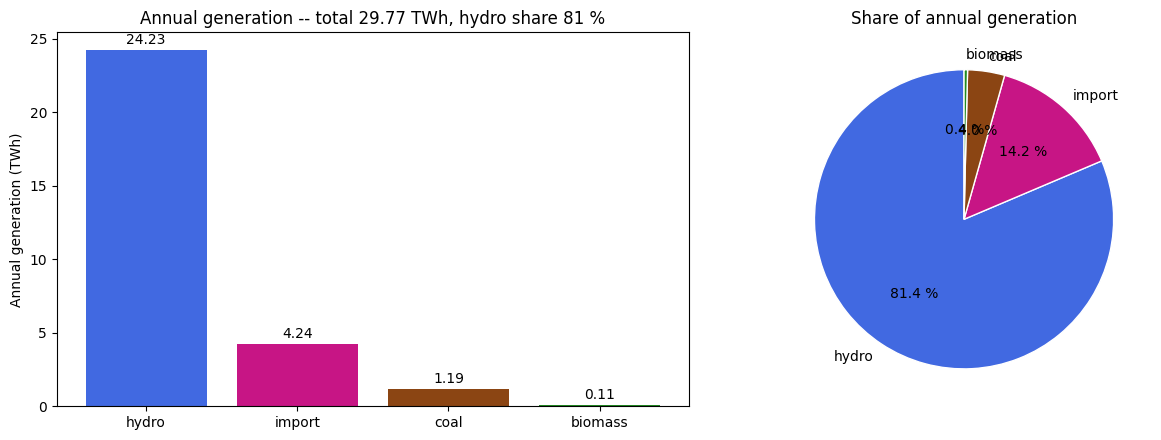

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
carrier_order = ['hydro', 'import', 'coal', 'biomass']
vals = [annual.get(c, 0) for c in carrier_order]
colors = ['royalblue', 'mediumvioletred', 'saddlebrown', 'forestgreen']
axes[0].bar(carrier_order, vals, color=colors)
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.4, f'{v:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Annual generation (TWh)')
axes[0].set_title(f'Annual generation -- total {annual.sum():.2f} TWh, '
                  f'hydro share {100*annual["hydro"]/annual.sum():.0f} %')

shares_arr = np.array([annual.get(c, 0) for c in carrier_order])
axes[1].pie(shares_arr, labels=carrier_order, colors=colors, autopct='%.1f %%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Share of annual generation')
plt.tight_layout(); plt.show()

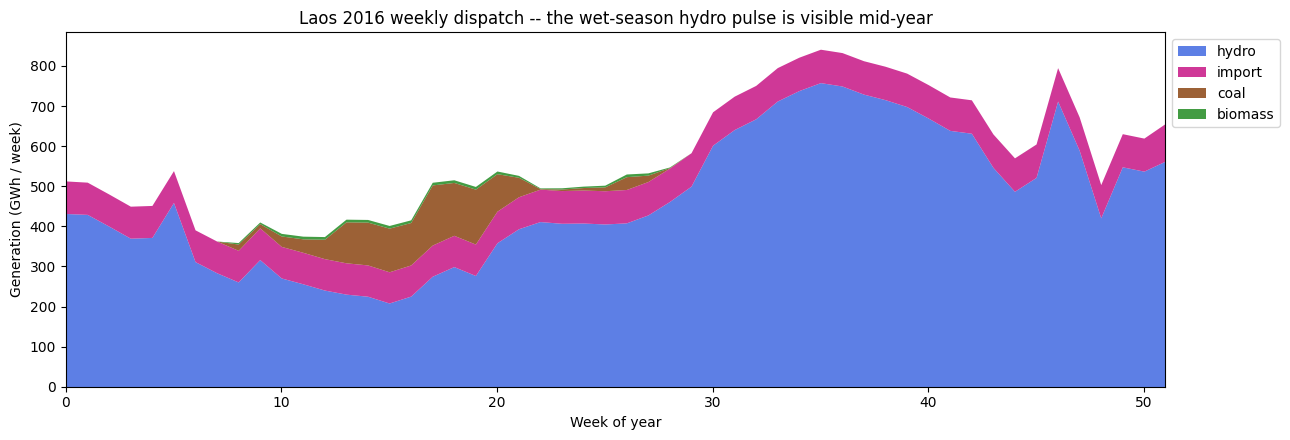

In [6]:
gen_df['week'] = ((gen_df['hour'] - 1) // (24 * 7)).clip(upper=51)
weekly = (
    gen_df.groupby(['week', 'carrier'])['value'].sum().unstack().fillna(0) / 1e3
)
weekly = weekly[[c for c in carrier_order if c in weekly.columns]]
fig, ax = plt.subplots(figsize=(13, 4.5))
weekly.plot.area(ax=ax, color=colors[:len(weekly.columns)], linewidth=0, alpha=0.85)
ax.set_xlabel('Week of year'); ax.set_ylabel('Generation (GWh / week)')
ax.set_title('Laos 2016 weekly dispatch -- the wet-season hydro pulse is visible mid-year')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0)); ax.set_xlim(0, 51)
plt.tight_layout(); plt.show()

## 5. Notes

* **Hydro dominance.** With 30 plants totalling several GW of
  nameplate against 1.9 GW thermal, Laos is the textbook hydro-
  export system.  PREP-SHOT correctly reproduces hydro at ~80 %
  of annual generation -- nothing the LP can do but route
  must-take hydro through the system.
* **Augmented demand.** ~5.54 TWh of implied exports added to the
  demand profile to absorb hydro+import surplus during wet-season
  hours.  This is the bulk of Laos's actual export commitments to
  Thailand and Vietnam (matches the Chowdhury et al. discussion of
  Laos as a hydro-export hub).
* **Single-bus.** Same caveat as Cambodia: 69 buses + transmission
  topology dropped.  Adding it back is a plant-bus mapping
  exercise on top of the input data.

## See also

* PowNet Cambodia ([`Cambodia.ipynb`](../cambodia/Cambodia.ipynb))
  -- companion case, thermal-dominated.